In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# **Q1**

In [4]:
datadf=pd.read_csv('WISDM.csv')
#data cleaning
datadf['X'].fillna(datadf['X'].mean(),inplace=True)
datadf['Y'].fillna(datadf['Y'].mean(),inplace=True)
datadf['Z'] = pd.to_numeric(datadf['Z'].str.replace(';', ''))
datadf['Z'].fillna(datadf['Z'].mean(), inplace=True)
#scaling
x_sc=stats.zscore(datadf['X'])
y_sc=stats.zscore(datadf['Y'])
z_sc=stats.zscore(datadf['Z'])
x_sc=x_sc[(x_sc<3)|(x_sc>-3)]
y_sc=y_sc[(y_sc<3)|(y_sc>-3)]
z_sc=z_sc[(z_sc<3)|(z_sc>-3)]

datadf['X']=x_sc
datadf['Y']=y_sc
datadf['Z']=z_sc

print(datadf)


<ipython-input-4-0c317111185f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datadf['X'].fillna(datadf['X'].mean(),inplace=True)
<ipython-input-4-0c317111185f>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

         User_ID Activity_Label        Timestamp             X         Y  \
0             33        Jogging   49105962326000 -2.088636e-01  0.800988   
1             33        Jogging   49106062271000  6.261730e-01  0.590435   
2             33        Jogging   49106112167000  6.102296e-01  0.533747   
3             33        Jogging   49106222305000 -1.969060e-01  1.665473   
4             33        Jogging   49106332290000 -2.806090e-01  0.715957   
...          ...            ...              ...           ...       ...   
1063917       19        Jogging  130192481447000 -2.770246e+00 -0.599300   
1063918       19        Jogging  130192521638000 -1.204623e+00 -1.431695   
1063919       19        Jogging  130192561555000 -1.015871e+00 -1.989102   
1063920       19        Jogging  130192641481000  6.543313e-02 -1.853838   
1063921       19        Jogging  130192681490000  1.624477e-17  0.000000   

                    Z  
0        1.960162e-02  
1        1.135716e-01  
2       -1.0284

<ipython-input-4-0c317111185f>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datadf['Z'].fillna(datadf['Z'].mean(), inplace=True)


# **Q2**

In [ ]:
#visualising
activity_groups = datadf.groupby('Activity_Label')

for activity, group in activity_groups:
  plt.figure(figsize=(10, 6))
  plt.bar(group.index, group['X'], label='X Acceleration', alpha=0.7)
  plt.bar(group.index, group['Y'], label='Y Acceleration', alpha=0.7)
  plt.bar(group.index, group['Z'], label='Z Acceleration', alpha=0.7)
  plt.xlabel('time')
  plt.ylabel('acceleration')
  plt.title(f'acceleration values for {activity}')
  plt.legend()
  plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7d77f8ff24d0> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d77f8ff11b0> (for post_execute):


KeyboardInterrupt: 

In [ ]:
#summary statistics
mean1=datadf.groupby('Activity_Label')[['X','Y','Z']].mean()
print("mean: \n", mean1)
median=datadf.groupby('Activity_Label')[['X','Y','Z']].median()
print("meadian:\n", median)
sd=datadf.groupby('Activity_Label')[['X','Y','Z']].std()
print("standard deviation:\n", sd)
#magnitude
mag = np.sqrt(datadf['X']**2 + datadf['Y']**2 + datadf['Z']**2)
print("magnitude \n",mag)
meanmag=mag.mean()
print("mean of the magnitude:", meanmag)

# **Q3**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

X = datadf[['X', 'Y', 'Z']]
y = datadf['Activity_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for i in range(1,25):
  k = i

  knn_model = KNeighborsClassifier(n_neighbors=k)
  knn_model.fit(X_train, y_train)
  y_pred = knn_model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred, average='weighted')
  recall = recall_score(y_test, y_pred, average='weighted')
  print("k: ",k)
  print("accuracy: ", accuracy)
  print("precision: ", precision)
  print("recall: ", recall)

k:  1
accuracy:  0.548624198134267
precision:  0.5475770816439155
recall:  0.548624198134267
k:  2
accuracy:  0.49877575956951853
precision:  0.5397468344629627
recall:  0.49877575956951853
k:  3
accuracy:  0.5586812980238268
precision:  0.5543184932323116
recall:  0.5586812980238268
k:  4
accuracy:  0.5721549921282045
precision:  0.5567957649169898
recall:  0.5721549921282045
k:  5
accuracy:  0.5797683107361891
precision:  0.5574407450901221
recall:  0.5797683107361891
k:  6
accuracy:  0.5903658622553282
precision:  0.5619757077884917
recall:  0.5903658622553282
k:  7
accuracy:  0.599483046267359
precision:  0.566090973105543
recall:  0.599483046267359
k:  8
accuracy:  0.604577390323566
precision:  0.5693719334053602
recall:  0.604577390323566
k:  9
accuracy:  0.6099208120873182
precision:  0.5720765830741011
recall:  0.6099208120873182
k:  10
accuracy:  0.6138355617172263
precision:  0.5744678643595976
recall:  0.6138355617172263
k:  11
accuracy:  0.6170077778038866
precision:  0.577

# **Q4**

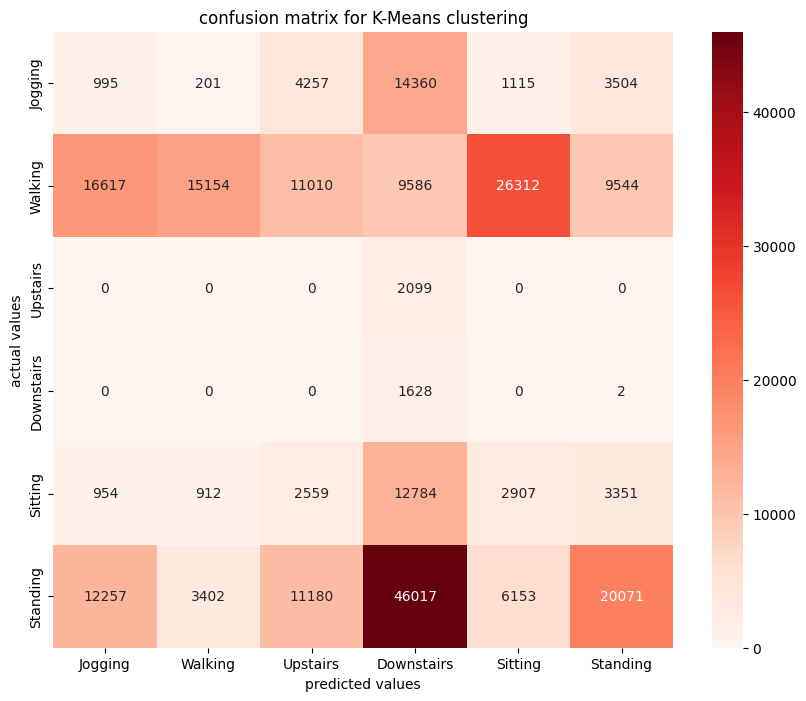

    Cluster Activity_Label  Count
0         0     Downstairs    201
1         0        Jogging  15154
2         0       Upstairs    912
3         0        Walking   3402
4         1     Downstairs   3504
5         1        Jogging   9544
6         1       Standing      2
7         1       Upstairs   3351
8         1        Walking  20071
9         2     Downstairs   1115
10        2        Jogging  26312
11        2       Upstairs   2907
12        2        Walking   6153
13        3     Downstairs    995
14        3        Jogging  16617
15        3       Upstairs    954
16        3        Walking  12257
17        4     Downstairs   4257
18        4        Jogging  11010
19        4       Upstairs   2559
20        4        Walking  11180
21        5     Downstairs  14360
22        5        Jogging   9586
23        5        Sitting   2099
24        5       Standing   1628
25        5       Upstairs  12784
26        5        Walking  46017


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

X_cluster = datadf[['X', 'Y', 'Z']]

unique_activities = datadf['Activity_Label'].unique()
k = len(unique_activities)

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_cluster)
cluster_labels = kmeans.labels_

cluster_to_activity = {cluster: activity for cluster, activity in enumerate(unique_activities)}

predicted_activities = np.array([cluster_to_activity[cluster] for cluster in cluster_labels])

cm = confusion_matrix(datadf['Activity_Label'], predicted_activities)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=datadf['Activity_Label'].unique(),
            yticklabels=datadf['Activity_Label'].unique())
plt.xlabel('predicted values')
plt.ylabel('actual values')
plt.title('confusion matrix for K-Means clustering')
plt.show()

cluster_df = pd.DataFrame({'Activity_Label': datadf['Activity_Label'], 'Cluster': cluster_labels})
cluster_counts = cluster_df.groupby(['Cluster', 'Activity_Label']).size().reset_index(name='Count')
print(cluster_counts)
#after the third iteration the k-means algorithm is grouping similar activities together like walking and jogging,
#and moving upstairs adn downstairs which shows that the algorithm is working correctly. the confusion matrix has one
#major problem, it groups downstairs adn jogging, downstairs and walking together but the clusters solve this
#problem by the third iteration hence we can say that clustering works to some extent here.

# **Q5**

In [2]:
from sklearn.svm import SVC

kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    svm_model = SVC(kernel=kernel, C=1, gamma='scale')
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print('results for' ,kernel)
    print("accuracy:", accuracy)
    print("precision:", precision)
    print("recall:", recall)

C_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]

best_accuracy = 0
best_params = {}

for kernel in kernels:
  for C in C_values:
      for gamma in gamma_values:
        svm_model = SVC(kernel=kernel, C=C, gamma=gamma)
        svm_model.fit(X_train, y_train)
        y_pred = svm_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        if accuracy > best_accuracy:
         best_accuracy = accuracy
         best_params = {'C': C, 'gamma': gamma, 'kernel':kernel}

print("best hyperparameters:", best_params)
print("best accuracy:", best_accuracy)

NameError: name 'X_train' is not defined

NameError: name 'X_train' is not defined

# **SUMMARY** **REPORT**

○ Overview of the data

apart from the dataset being very large, there are also too many outliers which need to be removed. additionally the data values are also very different from each other in a sense that they need to be normalised so that they can be worked on, eg some values are in negative while some are in positive and some are very low and some are very high, hence all 3 columns(X,Y,Z) need to be normailsed and outliers need to be removed as well. the activity labels can also be encoded with numbers like 1 for walking, 2 for jogging which will make it easier to work on the data.
  

○ Key findings from each model

 KNN:

it shows various values of k from 1 to 24 and shows the accuracy, precision and recall values with each. we can then determine the best value for k by looking at the values.

 K-Means:

 it used te number of activities as the number of clusters and visualised a confusion matrix. it grouped similar activities like walking and jogging, upstairs adn downstairs together but some were misclassified like downstairs with walking and jogging.

 SVM:

 it compared with different kernels and performed a grid search to find the best parameters and evaluated using accuracy, precision and recall and then identifies the best parameter using the accuracy.

○ Comparison of model performances

KNN:it iterates through many values of k and the best value for accuracy, precision and recall can be determined by looking at the results. it is also easier and faster to train than the other models.

K-Means: looking at the confusion matrix we can determoine the values of accuracy, precision and recall and on the surface level it seems more accurate than KNN but generally it is better for showing clustering performance. it is also generally faster and gives quicker results than SVM.

SVM: it trains with 3 different kernels and the accuracy, precision and recall are printed for each so the training time is significantly slower as it has to train with hyperparameters and relatively big dataset size.

to see which model works the best we need to collect the accuracy, precision and recall values of all 3 and compare them. we also need to keep in mind the execution time as it is important if bigger datasets are used.



○ Final reflections on the best approach for this dataset

SVM seems the best as it gives a higher accuracy but is also very slow which may hinder future findings if a larger dataset is used. KNN is much less accurate but is faster and K-means is better for grouping and so its performance cannot be assesed with accuracy so in the end it all depends on the way the problem; if it requires more accurate results without time constraints SVM is best but if there is time constraint then KNN is suitable and if data insights are required then K-Means.